# Persona B — Clasificación de Fraude Financiero

**Proyecto:** Sistema Inteligente de Detección y Análisis de Fraude Financiero  
**Responsabilidad:** Preprocesamiento, entrenamiento de modelos de clasificación, evaluación y exportación del mejor modelo.

---

### Contenido
1. Importación de librerías
2. Carga del dataset
3. Preprocesamiento
4. Entrenamiento de modelos
5. Evaluación y comparación
6. Exportación del mejor modelo

## 1. Importación de librerías

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Preprocesamiento
from sklearn.preprocessing import StandardScaler # El dataset no posee valores nulos, por lo que solo se escalarán los datos.
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluación
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

print('Librerías importadas correctamente')

✅ Librerías importadas correctamente


> **Nota:** Si falta alguna librería, se instala de la siguiente manera:
> ```
> pip install imbalanced-learn scikit-learn pandas numpy matplotlib seaborn joblib
> ```

---
## 2. Carga del dataset

In [ ]:
df = pd.read_csv('../data/creditcard.csv')

print(f'Dimensiones del dataset: {df.shape}')
print(f'\nDistribución de clases:')
print(df['Class'].value_counts())
print(f'\nPorcentaje de fraude: {df["Class"].mean()*100:.4f}%')
df.head()

Dimensiones del dataset: (284807, 31)

Distribución de clases:
Class
0    284315
1       492
Name: count, dtype: int64

Porcentaje de fraude: 0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


---
## 3. Preprocesamiento

### 3.1 Revisión rápida de nulos

In [4]:
print('Valores nulos por columna:')
print(df.isnull().sum().sum(), '← total de nulos en el dataset')

Valores nulos por columna:
0 ← total de nulos en el dataset


### 3.2 Separar features y target

In [5]:
# X: todas las columnas excepto 'Class'
# y: columna objetivo (0 = legítimo, 1 = fraude)
X = df.drop(columns=['Class'])
y = df['Class']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (284807, 30)
y shape: (284807,)


### 3.3 Escalar columnas 'Amount' y 'Time'

Las columnas V1-V28 ya vienen escaladas (PCA). Solo necesitamos escalar `Amount` y `Time`.

In [6]:
scaler = StandardScaler()

X = X.copy()
X[['Amount', 'Time']] = scaler.fit_transform(X[['Amount', 'Time']])

print('✅ Escalado aplicado a Amount y Time')
X[['Amount', 'Time']].describe()

✅ Escalado aplicado a Amount y Time


,Amount,Time
count,2.848070e+05,2.848070e+05
mean,2.913952e-17,-3.065637e-16
std,1.000002e+00,1.000002e+00
min,-3.532294e-01,-1.996583e+00
25%,-3.308401e-01,-8.552120e-01
50%,-2.652715e-01,-2.131453e-01
75%,-4.471707e-02,9.372174e-01
max,1.023622e+02,1.642058e+00


### 3.4 Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Mantiene proporción de clases en ambos splits
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')
print(f'\nFraudes en train: {y_train.sum()} ({y_train.mean()*100:.3f}%)')
print(f'Fraudes en test:  {y_test.sum()} ({y_test.mean()*100:.3f}%)')

Train: 227845 muestras
Test:  56962 muestras

Fraudes en train: 394 (0.173%)
Fraudes en test:  98 (0.172%)


### 3.5 Balanceo con SMOTE

El dataset está muy desbalanceado (~0.17% de fraudes). SMOTE genera muestras sintéticas de la clase minoritaria **solo en el conjunto de entrenamiento**.

In [8]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('Distribución ANTES de SMOTE:')
print(pd.Series(y_train).value_counts())

print('\nDistribución DESPUÉS de SMOTE:')
print(pd.Series(y_train_bal).value_counts())

Distribución ANTES de SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

Distribución DESPUÉS de SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


---
## 4. Entrenamiento de modelos

Entrenamos 3 modelos sobre los datos balanceados.

In [9]:
modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

modelos_entrenados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train_bal, y_train_bal)
    modelos_entrenados[nombre] = modelo
    print(f'✅ {nombre} entrenado')

✅ Logistic Regression entrenado
✅ Decision Tree entrenado
✅ Random Forest entrenado


---
## 5. Evaluación y comparación de modelos

In [10]:
resultados = []

for nombre, modelo in modelos_entrenados.items():
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    
    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, y_proba)
    
    resultados.append({
        'Modelo':     nombre,
        'Precision':  round(report['1']['precision'], 4),
        'Recall':     round(report['1']['recall'], 4),
        'F1-score':   round(report['1']['f1-score'], 4),
        'ROC-AUC':    round(auc, 4)
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
df_resultados

,Precision,Recall,F1-score,ROC-AUC
Modelo,,,,
Logistic Regression,0.0581,0.9184,0.1094,0.9698
Decision Tree,0.0798,0.8061,0.1452,0.8951
Random Forest,0.8454,0.8367,0.8410,0.9731


### 5.1 Visualización comparativa

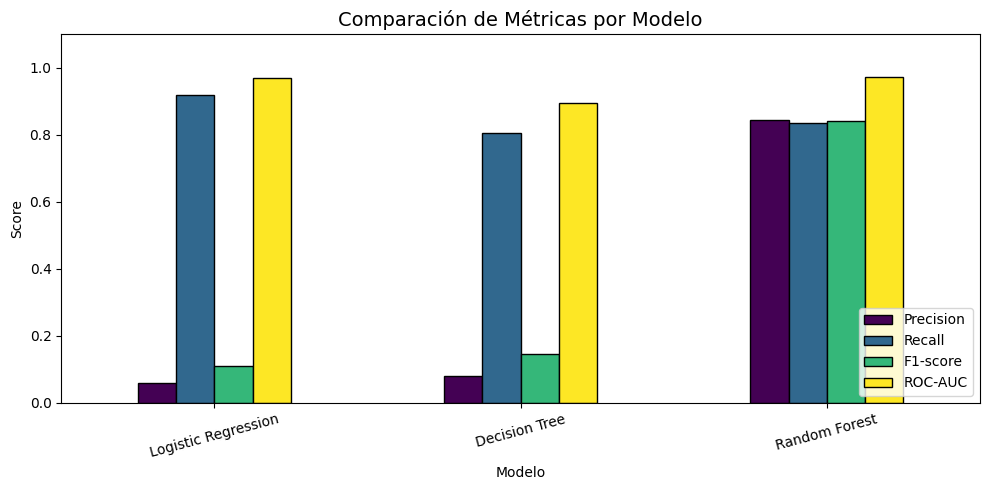

📊 Gráfica guardada en reports/comparacion_modelos.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
df_resultados.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='black')
ax.set_title('Comparación de Métricas por Modelo', fontsize=14)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')
ax.set_xticklabels(df_resultados.index, rotation=15)
plt.tight_layout()
plt.savefig('../reports/comparacion_modelos.png', dpi=150)
plt.show()
print('📊 Gráfica guardada en reports/comparacion_modelos.png')

### 5.2 Matrices de confusión

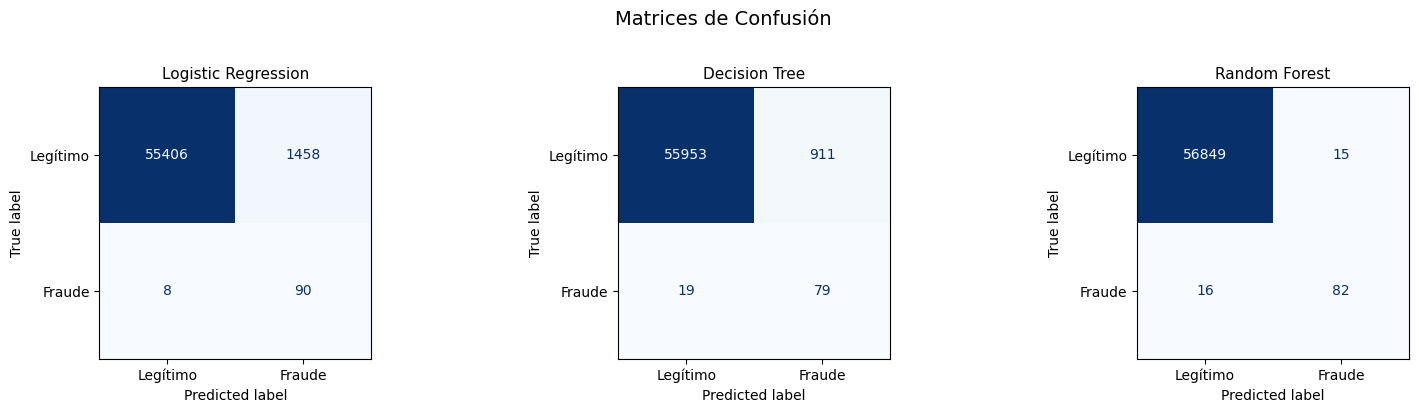

📊 Gráfica guardada en reports/matrices_confusion.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (nombre, modelo) in zip(axes, modelos_entrenados.items()):
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legítimo', 'Fraude'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre, fontsize=11)

plt.suptitle('Matrices de Confusión', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../reports/matrices_confusion.png', dpi=150)
plt.show()
print('📊 Gráfica guardada en reports/matrices_confusion.png')

### 5.3 Curvas ROC

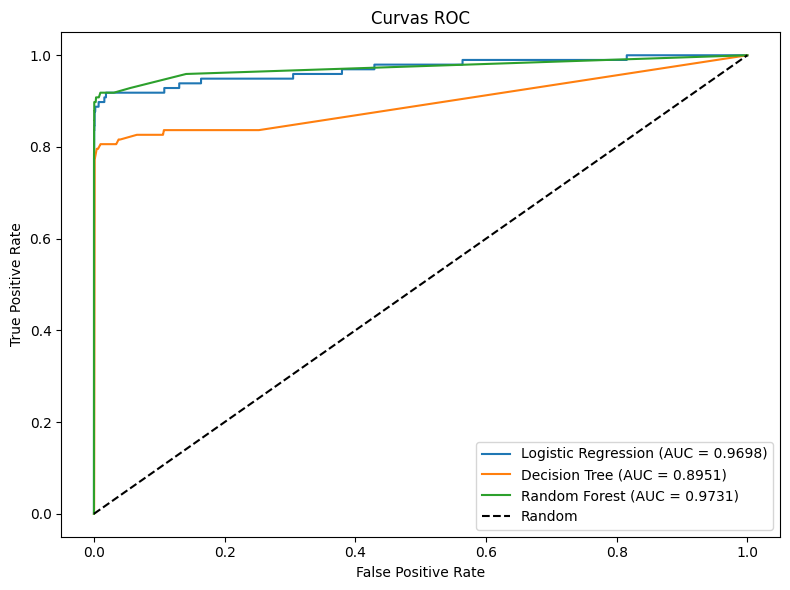

📊 Gráfica guardada en reports/curvas_roc.png


In [13]:
plt.figure(figsize=(8, 6))

for nombre, modelo in modelos_entrenados.items():
    y_proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/curvas_roc.png', dpi=150)
plt.show()
print('📊 Gráfica guardada en reports/curvas_roc.png')

### 5.4 Selección del mejor modelo

Usamos **F1-score** como criterio principal porque el dataset está desbalanceado.

In [14]:
mejor_nombre = df_resultados['F1-score'].idxmax()
mejor_modelo = modelos_entrenados[mejor_nombre]

print(f'🏆 Mejor modelo: {mejor_nombre}')
print(f'   F1-score:  {df_resultados.loc[mejor_nombre, "F1-score"]}')
print(f'   ROC-AUC:   {df_resultados.loc[mejor_nombre, "ROC-AUC"]}')
print(f'   Precision: {df_resultados.loc[mejor_nombre, "Precision"]}')
print(f'   Recall:    {df_resultados.loc[mejor_nombre, "Recall"]}')

🏆 Mejor modelo: Random Forest
   F1-score:  0.841
   ROC-AUC:   0.9731
   Precision: 0.8454
   Recall:    0.8367


---
## 6. Exportación del mejor modelo

In [15]:
import os
os.makedirs('../models', exist_ok=True)

# Guardar modelo
joblib.dump(mejor_modelo, '../models/classification_model.pkl')

# Guardar también el scaler (lo necesitará Persona C para la app)
joblib.dump(scaler, '../models/scaler.pkl')

print(f'✅ Modelo guardado en: models/classification_model.pkl')
print(f'✅ Scaler guardado en: models/scaler.pkl')
print(f'\n📦 Modelo exportado: {mejor_nombre}')

✅ Modelo guardado en: models/classification_model.pkl
✅ Scaler guardado en: models/scaler.pkl

📦 Modelo exportado: Random Forest


---
## Resumen final

In [16]:
print('='*55)
print('         RESUMEN — PERSONA B (CLASIFICACIÓN)')
print('='*55)
print(f'Dataset:          creditcard.csv')
print(f'Muestras train:   {X_train_bal.shape[0]} (después de SMOTE)')
print(f'Muestras test:    {X_test.shape[0]}')
print()
print('Resultados por modelo:')
print(df_resultados.to_string())
print()
print(f'Mejor modelo:     {mejor_nombre}')
print(f'Archivos exportados:')
print(f'  → models/classification_model.pkl')
print(f'  → models/scaler.pkl')
print(f'  → reports/comparacion_modelos.png')
print(f'  → reports/matrices_confusion.png')
print(f'  → reports/curvas_roc.png')
print('='*55)

         RESUMEN — PERSONA B (CLASIFICACIÓN)
Dataset:          creditcard.csv
Muestras train:   454902 (después de SMOTE)
Muestras test:    56962

Resultados por modelo:
                     Precision  Recall  F1-score  ROC-AUC
Modelo                                                   
Logistic Regression     0.0581  0.9184    0.1094   0.9698
Decision Tree           0.0798  0.8061    0.1452   0.8951
Random Forest           0.8454  0.8367    0.8410   0.9731

Mejor modelo:     Random Forest
Archivos exportados:
  → models/classification_model.pkl
  → models/scaler.pkl
  → reports/comparacion_modelos.png
  → reports/matrices_confusion.png
  → reports/curvas_roc.png
